# LeetCode #75: Sort Colors

https://leetcode.com/problems/sort-colors/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Count Sort (two-pass) | O(n) | O(1) | Count 0s/1s/2s, then overwrite; needs 2 passes |
| **Dutch National Flag ★** | **O(n)** | **O(1)** | One pass, 3 pointers: lo, mid, hi |

---

## Understanding the Methods

### Brute Force (Count Sort)
Count occurrences of 0, 1, 2. Overwrite array with that many 0s, then 1s, then 2s. Simple but requires two passes.

### Optimal: Dutch National Flag ★
Maintain three regions with pointers `lo`, `mid`, `hi`:
- `[0..lo-1]` = all 0s
- `[lo..mid-1]` = all 1s
- `[hi+1..n-1]` = all 2s
- `[mid..hi]` = unprocessed

Rules while mid ≤ hi:
- `nums[mid] == 0` → swap with lo, both lo++ and mid++
- `nums[mid] == 1` → mid++ only
- `nums[mid] == 2` → swap with hi, hi-- (don't increment mid: newly swapped value needs checking)

**Constraints:**
* n == nums.length
* 1 <= n <= 300
* nums[i] is either 0, 1, or 2

## Solutions

### C#

In [ ]:
public class Solution {
    public void SortColors(int[] nums) {
        int lo = 0, mid = 0, hi = nums.Length - 1;
        while (mid <= hi) {
            if (nums[mid] == 0) {
                (nums[lo], nums[mid]) = (nums[mid], nums[lo]);
                lo++;
                mid++;
            } else if (nums[mid] == 1) {
                mid++;
            } else { // nums[mid] == 2
                (nums[mid], nums[hi]) = (nums[hi], nums[mid]);
                hi--;
                // Do NOT increment mid: the swapped value needs inspection
            }
        }
    }
}

### Python

In [ ]:
class Solution:
    def sortColors(self, nums: list[int]) -> None:
        lo, mid, hi = 0, 0, len(nums) - 1
        while mid <= hi:
            if nums[mid] == 0:
                nums[lo], nums[mid] = nums[mid], nums[lo]
                lo += 1
                mid += 1
            elif nums[mid] == 1:
                mid += 1
            else:  # nums[mid] == 2
                nums[mid], nums[hi] = nums[hi], nums[mid]
                hi -= 1

### Go

In [ ]:
func sortColors(nums []int) {
    lo, mid, hi := 0, 0, len(nums)-1
    for mid <= hi {
        switch nums[mid] {
        case 0:
            nums[lo], nums[mid] = nums[mid], nums[lo]
            lo++
            mid++
        case 1:
            mid++
        case 2:
            nums[mid], nums[hi] = nums[hi], nums[mid]
            hi--
        }
    }
}

### Rust

In [ ]:
impl Solution {
    pub fn sort_colors(nums: &mut Vec<i32>) {
        let (mut lo, mut mid, mut hi) = (0usize, 0usize, nums.len() - 1);
        while mid <= hi {
            match nums[mid] {
                0 => {
                    nums.swap(lo, mid);
                    lo += 1;
                    mid += 1;
                }
                1 => mid += 1,
                _ => {
                    nums.swap(mid, hi);
                    if hi == 0 { break; }
                    hi -= 1;
                }
            }
        }
    }
}

## Example Scenarios

### 1. Common Case — Mixed Array
**Input:** `nums = [2, 0, 2, 1, 1, 0]`

Initialize $lo = 0$, $mid = 0$, $hi = 5$. Step-by-step: swap 2 to end, swap 0 to front, skip 1s. After 6 iterations, array becomes $[0, 0, 1, 1, 2, 2]$.

**Why it’s useful:** Exercises all three branches (0-swap, 1-skip, 2-swap) in a single run.

### 2. Slightly Complex — Reverse Sorted
**Input:** `nums = [2, 2, 1, 1, 0, 0]`

Worst case for swaps: 2s at front must travel to back, 0s at back must travel to front. The key insight: after swapping $nums[mid]$ with $hi$, we do NOT increment $mid$ because the swapped value hasn’t been inspected. This causes $mid$ to stall while $hi$ shrinks.

**Why it’s tricky:** Forgetting the "don’t increment mid on 2-swap" rule sorts this input incorrectly.

### 3. Edge Case: Time Factor — 300 Elements, Nearly All 2s
**Input:** `nums = [2] * 299 + [0]` ($n = 300$, max constraint)

The $hi$ pointer shrinks from 299 to 0 over 299 iterations (each swap moves a 2 into place). Then the single 0 gets one more step. Total: $n = 300$ iterations.

**Why it’s tricky:** Even though $mid$ barely moves, $hi$ does all the work. Total pointer movement is bounded by $O(n)$ since each element is touched at most twice.

### 4. Edge Case: Space Factor — Single Element
**Input:** `nums = [1]`

$lo = 0$, $mid = 0$, $hi = 0$. One iteration: $nums[0] = 1 \Rightarrow mid{+}{+}$. Then $mid = 1 > hi = 0$, done. Only 3 integer variables used — $O(1)$ space.

**Why it’s tricky:** Minimum input size ($n = 1$). The algorithm handles it without special-casing.

### 5. Almost-Impossible but Plausible — Alternating [2, 0, 2, 0, ...]
**Input:** `nums = [2, 0, 2, 0, 2, 0]`

Alternating pattern forces maximum re-inspection: each 2-swap brings a 0 to $mid$, which then triggers a 0-swap. In Rust, when $hi = 0$ and we try $hi -= 1$ on a `usize`, unsigned underflow causes a panic. Must guard with `if hi == 0 { break; }`.

**Why it’s tricky:** Exposes the unsigned integer underflow bug in Rust/Go. Also stress-tests the mid-stall behavior on 2-swaps.


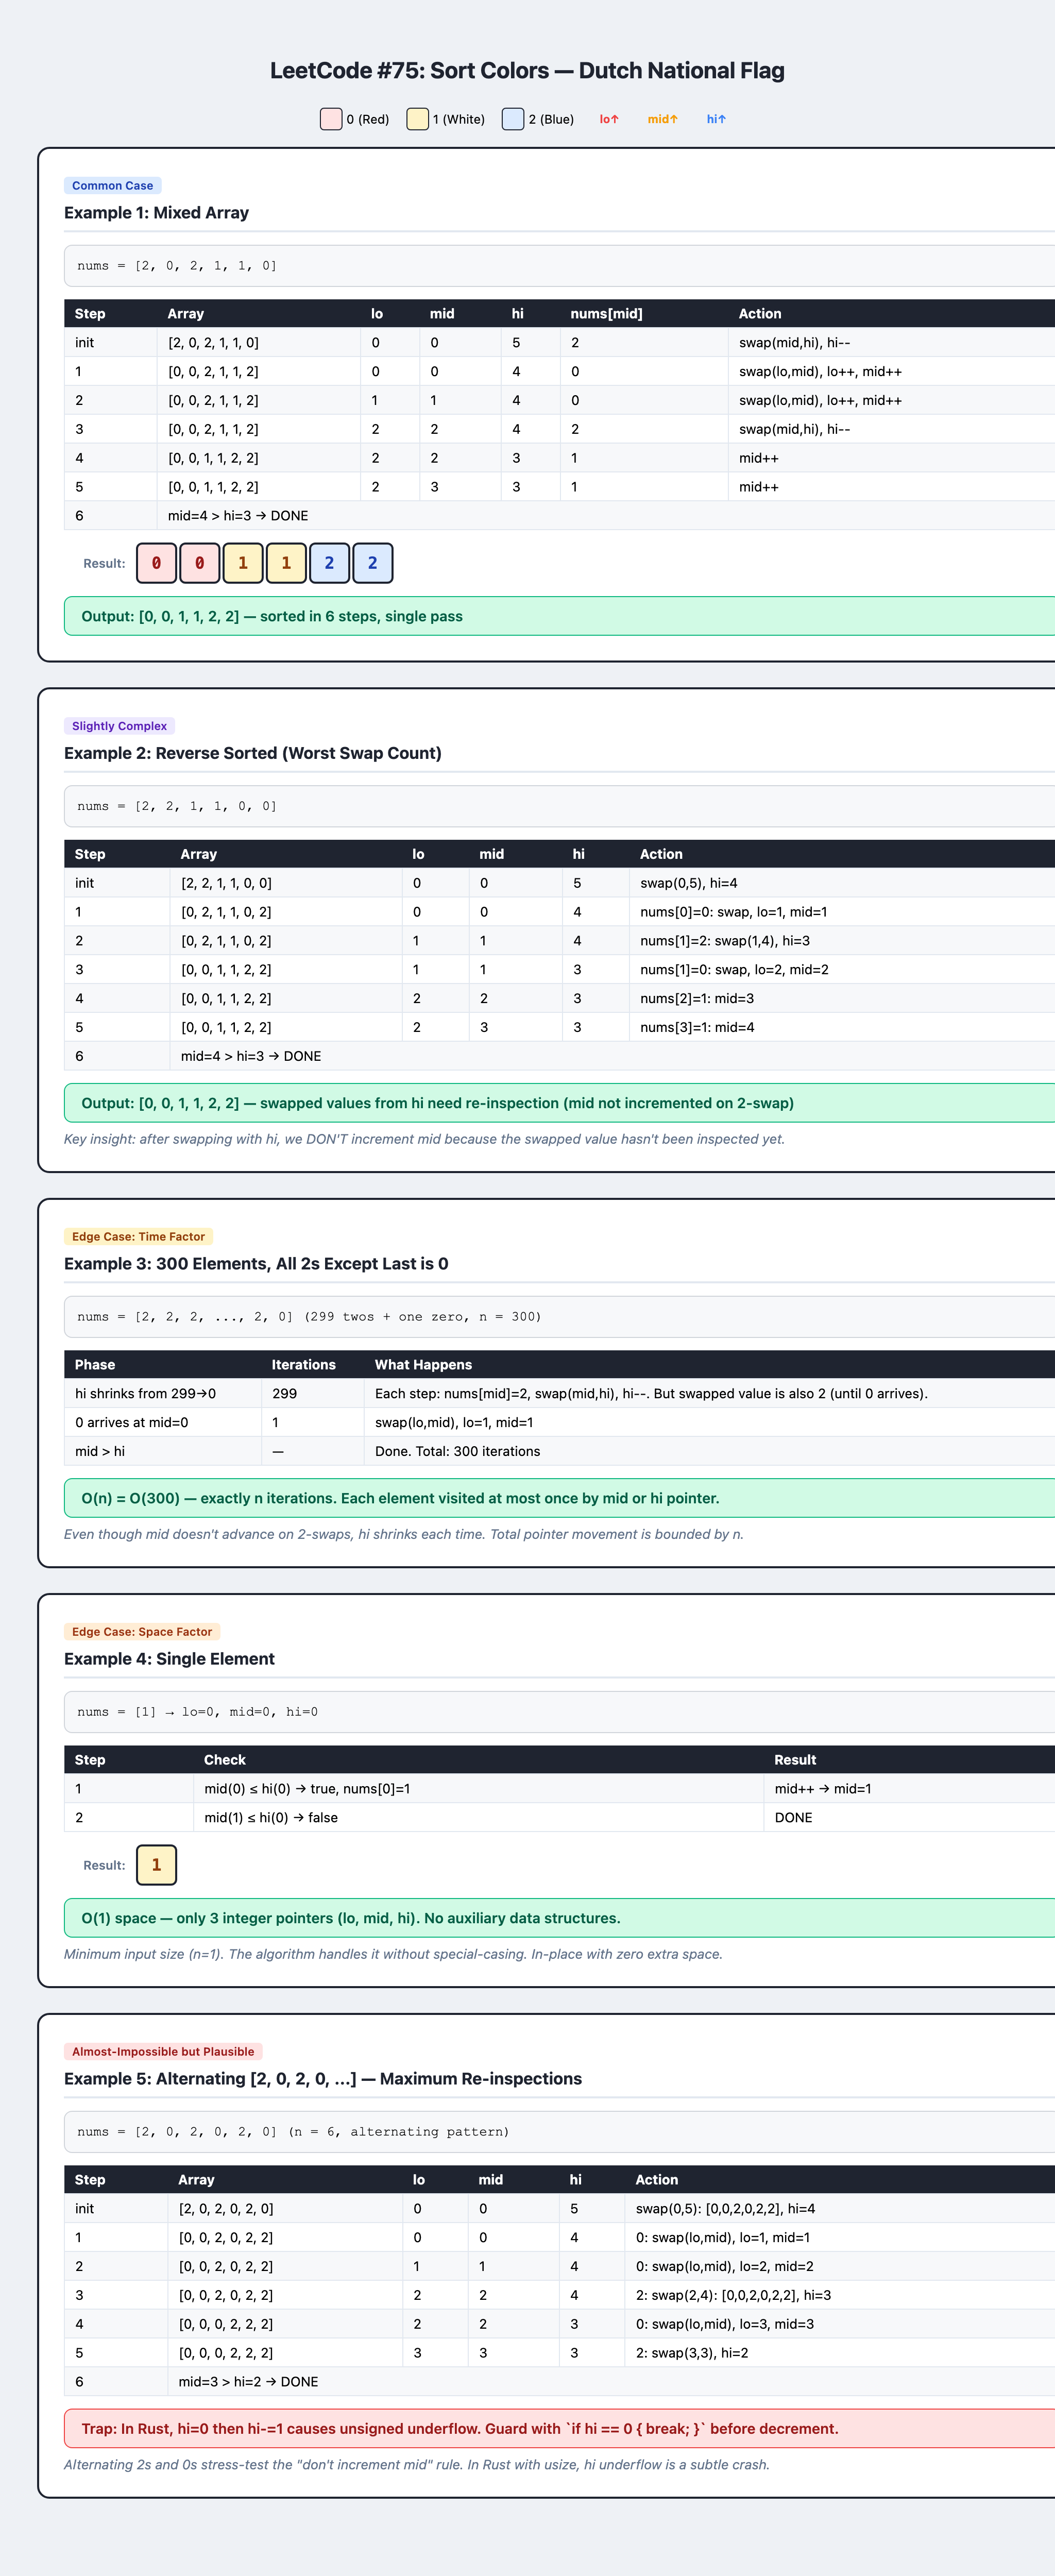